# Opium Snippets Topic Modelling

This notebook builds the first backbone of the topic modelling pipeline. Each extracted snippet is treated as one document, so the model captures the themes that appear around opium-related mentions rather than modelling whole books.

## Setup

In [40]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
from pathlib import Path
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

# Add parent directory to the search path
sys.path.append('..')   

from utils.topic_modelling import *
from utils.constants import KEYWORDS

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 180)

In [42]:
DATA_DIR = Path("../../data/snippets")
OUTPUT_DIR = Path("../../data/topic_modelling")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SNIPPETS_PARQUET = DATA_DIR / "total_snippets.parquet"
SNIPPETS_CSV = DATA_DIR / "total_snippets.csv"

RANDOM_STATE = 23

## Load Snippets as Documents

In [43]:
def load_snippets(parquet_path=SNIPPETS_PARQUET, csv_path=SNIPPETS_CSV):
    """Load snippets, preferring parquet because it keeps the intended schema clean."""
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    return pd.read_csv(csv_path, index_col=0)


df_raw = load_snippets()
df_raw.head()

,Book_ID,Keyword,Full_Context
0,24,poppy,"had been mowing the better part of an hour, he heard the rattle of a light cart on the road behind him. Supposing that it was his sister coming back from one of her farms, he k..."
1,24,poppy,"Marie bent down and opened the oven door. A delicious hot fragrance blew out into the tidy kitchen. “My, somet’ing smell good!” She turned to Alexandra with a wink, her three y..."
2,36,black smoke,"below the house were burning while I did this, and the palings up the road glowed red. While I was occupied in this way, one of the dismounted hussars came running up. He was g..."
3,36,black smoke,"her on the tail of the dog cart, and then caught the reins and jumped up into the driver’s seat beside my wife. In another moment we were clear of the smoke and noise, and span..."
4,36,black smoke,"smoke already extended far away to the east and west—to the Byfleet pine woods eastward, and to Woking on the west. The road was dotted with people running towards us. And very..."


In [44]:
df_raw.info()
df_raw["Keyword"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 3857 entries, 0 to 3856
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Book_ID       3857 non-null   int64
 1   Keyword       3857 non-null   str  
 2   Full_Context  3857 non-null   str  
dtypes: int64(1), str(2)
memory usage: 4.3 MB


Keyword
opium          1320
poppy          1114
morphine        355
black smoke     297
narcotic        235
anodyne         203
laudanum        152
soporific        91
nepenthe         42
heroin           25
paregoric        17
chandu            5
codein            1
Name: count, dtype: int64

`poppy` and `black smoke` are useful for extraction experiments but can pull the model toward botanical or smoke/fire contexts. The first modelling pass excludes them by default; change `EXCLUDED_KEYWORDS` if you want to compare.

In [45]:
EXCLUDED_KEYWORDS = {"poppy", "black smoke"}

df_docs = (
    df_raw
    .dropna(subset=["Full_Context"])
    .loc[lambda d: ~d["Keyword"].str.lower().isin(EXCLUDED_KEYWORDS)]
    .drop_duplicates(subset=["Book_ID", "Keyword", "Full_Context"])
    .reset_index(drop=True)
    .copy()
)

df_docs["snippet_id"] = df_docs.index
df_docs = df_docs[["snippet_id", "Book_ID", "Keyword", "Full_Context"]]

print(f"Documents/snippets: {len(df_docs):,}")
print(f"Books represented: {df_docs['Book_ID'].nunique():,}")
df_docs["Keyword"].value_counts()

Documents/snippets: 2,446
Books represented: 868


Keyword
opium        1320
morphine      355
narcotic      235
anodyne       203
laudanum      152
soporific      91
nepenthe       42
heroin         25
paregoric      17
chandu          5
codein          1
Name: count, dtype: int64

## Prepare Text

In [46]:
TARGET_TERMS = set(df_docs["Keyword"].str.lower().unique()) | set(KEYWORDS)

TARGET_TERMS = {
                token
                for word in TARGET_TERMS
                for token in re.findall(r"\b[a-z][a-z-]{2,}\b", word.lower())
}

PROJECT_STOP_WORDS = {"said", "say"}
#     "gutenberg", "project", "ebook", "chapter", "said", "mr", "mrs", "miss",
#     "thou", "thy", "thee", "shall", "would", "could", "may", "like"
# }

STOP_WORDS = sorted(ENGLISH_STOP_WORDS | PROJECT_STOP_WORDS | TARGET_TERMS)


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[_\u2018\u2019\u201c\u201d]", " ", text)
    text = re.sub(r"[^a-z\s-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df_docs["document"] = df_docs["Full_Context"].map(clean_text)
df_docs = df_docs.loc[df_docs["document"].str.len() > 0].reset_index(drop=True)
documents = df_docs["document"].tolist()

df_docs[["snippet_id", "Keyword", "document"]].head()

,snippet_id,Keyword,document
0,0,opium,and scared you nothing to cry about i m the same old goods only a little dented sit down on my coat there and keep me company i ve got to lay still a bit dr archie and mr kronb...
1,1,paregoric,artist latinist transportation etc porters coarse washers and ironers mules fine ditto muleteers cows milkers total men animals grand total rations etc apparatus cases hams spr...
2,2,paregoric,us for quite a siege--and did they suppose zermatt would allow half a mile of men and mules to mysteriously disappear during any considerable time right above their noses and m...
3,3,paregoric,that a cow would naturally know more than a guide he took her by the tail and the result justified his judgment she nibbled her leisurely way downhill till it was near milking-...
4,4,paregoric,estimate of the elevation of the several localities above sea-level is pretty correct--for baedeker he only misses it about a hundred and eighty or ninety thousand feet i found...


## Vectorize Snippets

In [47]:
vectorizer = CountVectorizer(
    stop_words=STOP_WORDS,
    min_df=5,
    max_df=0.65,
    ngram_range=(1, 2),
    token_pattern=r"(?u)\b[a-z][a-z-]{2,}\b",
)

doc_term_matrix = vectorizer.fit_transform(documents)
feature_names = np.array(vectorizer.get_feature_names_out())

print(f"Document-term matrix: {doc_term_matrix.shape[0]:,} documents x {doc_term_matrix.shape[1]:,} terms")

Document-term matrix: 2,446 documents x 8,647 terms


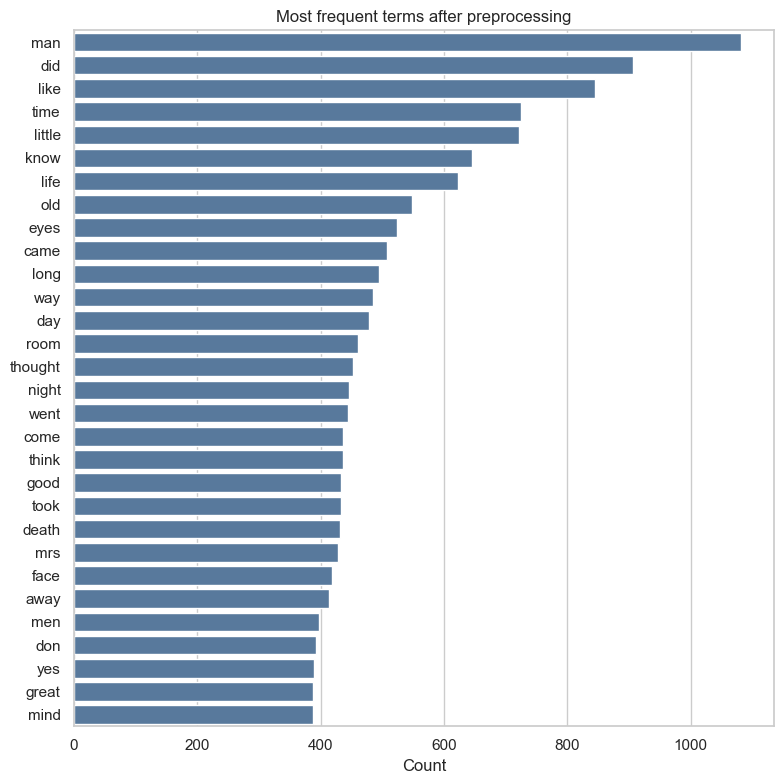

In [48]:
term_counts = np.asarray(doc_term_matrix.sum(axis=0)).ravel()
top_terms = (
    pd.DataFrame({"term": feature_names, "count": term_counts})
    .sort_values("count", ascending=False)
    .head(30)
)

plt.figure(figsize=(8, 8))
sns.barplot(data=top_terms, y="term", x="count", color="#4C78A8")
plt.title("Most frequent terms after preprocessing")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()

## Fit Candidate LDA Models

In [62]:
def fit_lda_model(n_topics, matrix=doc_term_matrix):
    model = LatentDirichletAllocation(
        n_components=n_topics,
        learning_method="batch",
        max_iter=25,
        random_state=RANDOM_STATE,
        evaluate_every=-1,
        n_jobs=-1,
    )
    doc_topic = model.fit_transform(matrix)
    return model, doc_topic


candidate_topic_counts = range(50, 100)
model_scores = []
candidate_models = {}

for n_topics in candidate_topic_counts:
    print(f"Computing topics for n_topics = {n_topics}...")
    model, doc_topic = fit_lda_model(n_topics)
    candidate_models[n_topics] = (model, doc_topic)
    model_scores.append({
        "n_topics": n_topics,
        "perplexity": model.perplexity(doc_term_matrix),
        "log_likelihood": model.score(doc_term_matrix),
    })

scores_df = pd.DataFrame(model_scores)
scores_df

Computing topics for n_topics = 50...
Computing topics for n_topics = 51...
Computing topics for n_topics = 52...
Computing topics for n_topics = 53...
Computing topics for n_topics = 54...
Computing topics for n_topics = 55...
Computing topics for n_topics = 56...
Computing topics for n_topics = 57...
Computing topics for n_topics = 58...
Computing topics for n_topics = 59...
Computing topics for n_topics = 60...
Computing topics for n_topics = 61...
Computing topics for n_topics = 62...
Computing topics for n_topics = 63...
Computing topics for n_topics = 64...
Computing topics for n_topics = 65...
Computing topics for n_topics = 66...
Computing topics for n_topics = 67...
Computing topics for n_topics = 68...
Computing topics for n_topics = 69...
Computing topics for n_topics = 70...
Computing topics for n_topics = 71...
Computing topics for n_topics = 72...
Computing topics for n_topics = 73...
Computing topics for n_topics = 74...
Computing topics for n_topics = 75...
Computing to

/Users/eglantinevialaneix/Desktop/History And The Digital/opium-gutenberg/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Computing topics for n_topics = 84...
Computing topics for n_topics = 85...
Computing topics for n_topics = 86...
Computing topics for n_topics = 87...
Computing topics for n_topics = 88...
Computing topics for n_topics = 89...
Computing topics for n_topics = 90...
Computing topics for n_topics = 91...
Computing topics for n_topics = 92...
Computing topics for n_topics = 93...
Computing topics for n_topics = 94...
Computing topics for n_topics = 95...
Computing topics for n_topics = 96...
Computing topics for n_topics = 97...
Computing topics for n_topics = 98...
Computing topics for n_topics = 99...


,n_topics,perplexity,log_likelihood
0,50,5562.449203,-1.569798e+06
1,51,5556.097792,-1.569590e+06
2,52,5732.074860,-1.575266e+06
3,53,5550.944266,-1.569421e+06
4,54,5549.872071,-1.569386e+06
5,55,5828.353205,-1.578298e+06
6,56,5683.042659,-1.573702e+06
7,57,5540.112706,-1.569065e+06
8,58,5819.025225,-1.578006e+06
9,59,5922.417099,-1.581212e+06


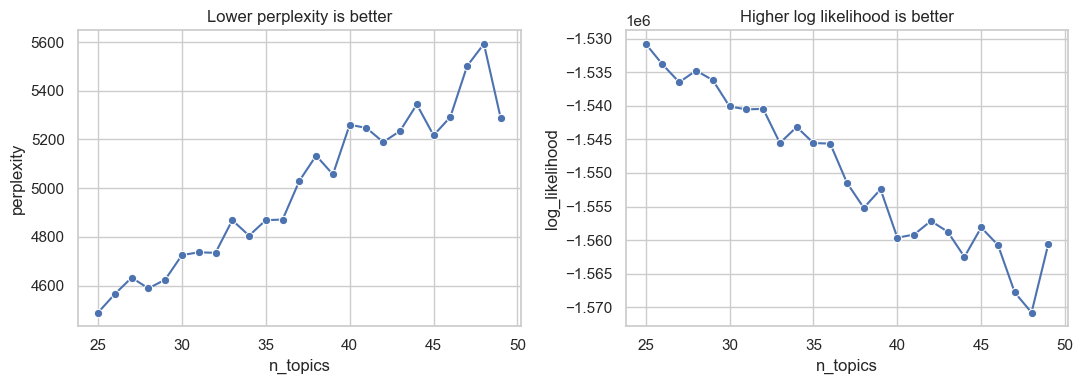

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.lineplot(data=scores_df, x="n_topics", y="perplexity", marker="o", ax=axes[0])
axes[0].set_title("Lower perplexity is better")
sns.lineplot(data=scores_df, x="n_topics", y="log_likelihood", marker="o", ax=axes[1])
axes[1].set_title("Higher log likelihood is better")
plt.tight_layout()

Perplexity and likelihood are useful diagnostics, but the final topic count should also be readable. Start with the best perplexity value, then adjust `SELECTED_N_TOPICS` after inspecting the topic terms and snippets.

In [59]:
SELECTED_N_TOPICS = int(scores_df.sort_values("perplexity").iloc[0]["n_topics"])
lda_model, doc_topic_matrix = candidate_models[SELECTED_N_TOPICS]

print(f"Selected topic count: {SELECTED_N_TOPICS}")

Selected topic count: 4


## Inspect Topics

In [52]:
def top_terms_by_topic(model, feature_names, n_terms=15):
    rows = []
    for topic_idx, weights in enumerate(model.components_):
        top_indices = weights.argsort()[::-1][:n_terms]
        rows.append({
            "topic": topic_idx,
            "top_terms": ", ".join(feature_names[top_indices]),
        })
    return pd.DataFrame(rows)


topics_df = top_terms_by_topic(lda_model, feature_names, n_terms=18)
topics_df

,topic,top_terms
0,0,"thou, thy, man, life, old, dana, kim, art, little, max, sending, thee, englishman, mrs, great, asked, sahib, things"
1,1,"sin, man, sir, sin sin, did, life, know, time, rita, think, chapter, mrs, great, quincey, case, lucien, sir lucien, nature"
2,2,"man, like, little, did, time, know, old, came, eyes, long, life, room, thought, night, went, way, day, come"
3,3,"death, did, case, administered, died, dose, poisoning, drug, yes, evidence, witness, question, doctor, diphtheria, disease, bliss, time, symptoms"


In [53]:
topic_columns = [f"topic_{i}" for i in range(SELECTED_N_TOPICS)]
doc_topics = pd.DataFrame(doc_topic_matrix, columns=topic_columns)

df_modelled = pd.concat([df_docs.reset_index(drop=True), doc_topics], axis=1)
df_modelled["dominant_topic"] = doc_topic_matrix.argmax(axis=1)
df_modelled["dominant_topic_weight"] = doc_topic_matrix.max(axis=1)

topic_summary = (
    df_modelled
    .groupby("dominant_topic")
    .agg(
        n_snippets=("snippet_id", "count"),
        n_books=("Book_ID", "nunique"),
        mean_weight=("dominant_topic_weight", "mean"),
    )
    .reset_index()
    .merge(topics_df, left_on="dominant_topic", right_on="topic", how="left")
    .drop(columns="topic")
    .sort_values("n_snippets", ascending=False)
)

topic_summary

,dominant_topic,n_snippets,n_books,mean_weight,top_terms
2,2,1969,848,0.871013,"man, like, little, did, time, know, old, came, eyes, long, life, room, thought, night, went, way, day, come"
3,3,186,11,0.897511,"death, did, case, administered, died, dose, poisoning, drug, yes, evidence, witness, question, doctor, diphtheria, disease, bliss, time, symptoms"
1,1,178,46,0.841450,"sin, man, sir, sin sin, did, life, know, time, rita, think, chapter, mrs, great, quincey, case, lucien, sir lucien, nature"
0,0,113,37,0.900651,"thou, thy, man, life, old, dana, kim, art, little, max, sending, thee, englishman, mrs, great, asked, sahib, things"


In [54]:
def representative_snippets(topic_id, n=5):
    topic_col = f"topic_{topic_id}"
    cols = ["snippet_id", "Book_ID", "Keyword", topic_col, "Full_Context"]
    return (
        df_modelled
        .sort_values(topic_col, ascending=False)
        [cols]
        .head(n)
    )


representative_snippets(topic_id=2, n=5)

,snippet_id,Book_ID,Keyword,topic_2,Full_Context
611,611,5054,opium,0.994350,"our way, or rather through an intricate maze of alleys and a labyrinth of blind recesses. We were apparently back of a store on Pell Street. It was the work of only a moment to..."
612,612,5054,opium,0.994340,"room, too, seemed to be piled with tea chests. Craig opened one. There lay piles and piles of opium tins, a veritable fortune in the drug. Mysterious pots and pans, strainers, ..."
610,610,5054,opium,0.994312,"Through a sort of short alley we groped our way, or rather through an intricate maze of alleys and a labyrinth of blind recesses. We were apparently back of a store on Pell Str..."
613,613,5054,opium,0.994305,"drug. Mysterious pots and pans, strainers, wooden vessels, and testing instruments were about. The odour of opium in the manufacture was unmistakable, for smoking opium is diff..."
609,609,5054,opium,0.994201,"the restaurant. Craig did not stop but leaped upstairs and then down again into a little back court by means of a fire-escape. Through a sort of short alley we groped our way, ..."


Change `topic_id` in the previous cell to read examples from each topic. The snippets are the interpretive checkpoint: if top terms look plausible but the snippets do not cohere, adjust preprocessing or topic count.

## Save First Outputs

In [55]:
EXPORT_TO_CSV = True
if EXPORT_TO_CSV:
    topics_path = OUTPUT_DIR / f"lda_{SELECTED_N_TOPICS}_topics_terms.csv"
    doc_topics_path = OUTPUT_DIR / f"lda_{SELECTED_N_TOPICS}_document_topics.csv"
    summary_path = OUTPUT_DIR / f"lda_{SELECTED_N_TOPICS}_topic_summary.csv"

    topics_df.to_csv(topics_path, index=False)
    topic_summary.to_csv(summary_path, index=False)
    df_modelled.drop(columns=["document"]).to_csv(doc_topics_path, index=False)

    print(f"Saved topic terms to: {topics_path}")
    print(f"Saved topic summary to: {summary_path}")
    print(f"Saved document-topic weights to: {doc_topics_path}")

Saved topic terms to: ../../data/topic_modelling/lda_4_topics_terms.csv
Saved topic summary to: ../../data/topic_modelling/lda_4_topic_summary.csv
Saved document-topic weights to: ../../data/topic_modelling/lda_4_document_topics.csv
